# SFR Fly Mean-Reversion — 5. Kalman filter

**Formulation: a fair value formed before the print, and drifting hedge ratios.**

Two distinct uses of the same machinery:

1. **Local level.** State `m_t = m_{t-1} + w_t`, observation `y_t = m_t + v_t`.
   The one-step-ahead prior uses information only through `t-1`, so the
   standardised innovation `z = (y_t - prior_t)/sqrt(pred_var_t)` is a genuine
   surprise. A trailing z-score, by contrast, compares today's print to a mean
   that already contains it. `q/r` is the only knob: larger means a
   faster-adapting fair value and a shorter memory.

2. **Dynamic hedge ratios.** Regress the belly on its two wings with
   coefficients that follow a random walk. This is the honest alternative to
   asserting `1/-2/1`, and unlike the rolling regression in the cointegration
   notebook it has no window discontinuity.

Both signals are causal by construction, which is the reason to prefer them:
`test_kalman_local_level_prior_is_causal` in `tests/test_rv_meanrev_core.py`
pins that perturbing `y[t]` cannot move `prior[t]`.

In [1]:
CONFIG = dict(
    primary_structure="3m",
    primary_window="liquid16",
    long_window="front8",
    cost_bp=1.5,
    n_packages=100,
    qs=(1e-5, 1e-4, 1e-3, 1e-2),   # state noise / observation noise ratio
    r_obs=1.0,
    deltas=(1e-6, 1e-4),           # hedge-ratio drift
    entry_zs=(1.5, 2.0, 2.5, 3.0),
    exits=("z0", "half", "t5", "t10"),
    directions=("fade", "momentum"),
    max_hold=20,
    lag=1,
)
CONFIG

{'primary_structure': '3m',
 'primary_window': 'liquid16',
 'long_window': 'front8',
 'cost_bp': 1.5,
 'n_packages': 100,
 'qs': (1e-05, 0.0001, 0.001, 0.01),
 'r_obs': 1.0,
 'deltas': (1e-06, 0.0001),
 'entry_zs': (1.5, 2.0, 2.5, 3.0),
 'exits': ('z0', 'half', 't5', 't10'),
 'directions': ('fade', 'momentum'),
 'max_hold': 20,
 'lag': 1}

In [2]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig
from RVUtils.MeanRev.signals import kalman_level_signal
from RVUtils.mean_reversion import (
    adf_pvalue, half_life, kalman_hedge_ratio, kalman_local_level,
)
from sfr_fly_meanrev_common import load_lab, per_slot_table, run_family

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 60)

BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
lab = load_lab(CONFIG["primary_structure"], CONFIG["primary_window"])
levels, st = lab["levels"], lab["struct"]
print(f"{levels.shape[1]} flies, {levels.shape[0]} sessions")

34 flies, 1150 sessions


## 1. What the filter's fair value looks like

The gap between the print and the prior is the tradeable quantity. If the
filter tracks the level closely the innovation is tiny and there is nothing to
fade; if it lags badly the innovation is mostly trend.

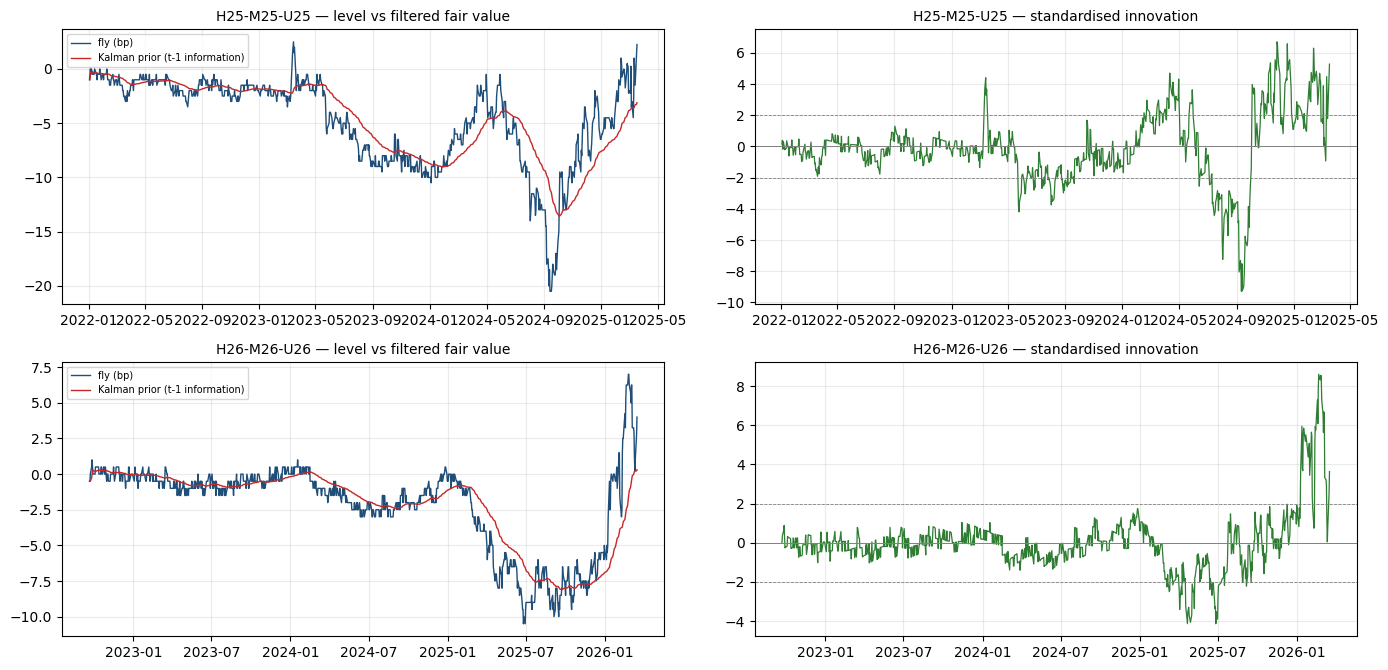

In [3]:
pick = [c for c in levels.columns if levels[c].notna().sum() > 700][:2]
fig, axes = plt.subplots(len(pick), 2, figsize=(14, 3.4 * len(pick)),
                         squeeze=False)
for i, c in enumerate(pick):
    s = levels[c].dropna()
    kf = kalman_local_level(s, q=1e-3, r=1.0)
    axes[i][0].plot(s.index, s.to_numpy(), lw=1.0, color="#1f4e79", label="fly (bp)")
    axes[i][0].plot(kf.index, kf["prior"].to_numpy(), lw=1.0, color="#c62828",
                    label="Kalman prior (t-1 information)")
    axes[i][0].set_title(f"{c} — level vs filtered fair value", fontsize=10)
    axes[i][0].legend(fontsize=7)
    axes[i][0].grid(alpha=0.25)
    axes[i][1].plot(kf.index, kf["z"].to_numpy(), lw=0.9, color="#2e7d32")
    axes[i][1].axhline(0, color="grey", lw=0.7)
    for lev in (-2, 2):
        axes[i][1].axhline(lev, color="grey", lw=0.6, ls="--")
    axes[i][1].set_title(f"{c} — standardised innovation", fontsize=10)
    axes[i][1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 2. Innovation properties across the panel

A well-specified filter leaves innovations that are close to white noise. If
they are strongly negatively autocorrelated the level over-reacts bar to bar
(fadeable); if positively, it trends.

In [4]:
rows = []
for q in CONFIG["qs"]:
    sig = kalman_level_signal(levels, q=q, r=CONFIG["r_obs"])
    ac = []
    for c in sig.columns:
        s = sig[c].dropna()
        if len(s) > 200:
            ac.append(float(s.autocorr(1)))
    rows.append({"q": q, "n_keys": len(ac), "mean_ac1": np.mean(ac),
                 "median_ac1": np.median(ac),
                 "mean_abs_z": float(sig.abs().stack().mean()),
                 "pct_beyond_2": float((sig.abs() > 2).to_numpy().mean())})
print("innovation diagnostics by filter speed:")
print(pd.DataFrame(rows).round(4).to_string(index=False))
print("\n  negative lag-1 autocorrelation of the innovation = bar-to-bar "
      "over-reaction, which is what a fade rule monetises.")

innovation diagnostics by filter speed:
     q  n_keys  mean_ac1  median_ac1  mean_abs_z  pct_beyond_2
0.0000      26    0.8765      0.9581      2.4998        0.1417
0.0001      26    0.8576      0.9447      2.1065        0.1235
0.0010      26    0.7955      0.9156      1.4604        0.0862
0.0100      26    0.6744      0.7856      0.8860        0.0460

  negative lag-1 autocorrelation of the innovation = bar-to-bar over-reaction, which is what a fade rule monetises.


## 3. Backtest — local-level innovation


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/128 configs


  50/128 configs


  75/128 configs


  100/128 configs


  125/128 configs


  128 configs | median -561.00bp | IQR [-764.88, -427.38] | 0% net-positive | best -184.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
    q  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
0.010      3.0         z0      fade       171     0.439      -1.079       -184.50      -461250.0  -1.051    -191.75
0.010      3.0       half      fade       162     0.389      -1.213       -196.50      -491250.0  -1.094    -206.00
0.001      3.0       half      fade       206     0.354      -1.055       -217.25      -543125.0  -0.924    -217.75
0.001      3.0         z0      fade       214     0.355      -1.151       -246.25      -615625.0  -0.919    -246.75
0.010      3.0        t10  momentum       193     0.254      -1.456       -281.00      -702500.0  -1.674    -301.00
0.010      2.5       half      fade       206     0.340      -1.394       -287.25      -718125.0  -1.408    -293.25
0.010      3.0       half

5. Kalman local-level (3m, liquid16) - best config  |  fade|z3.0|z0|hold20|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  standardised one-step-ahead innovation
  trades   171   skipped    2   hit 44%   avg -1.079bp   avg hold 11.0d
  total    -184.50bp   $     -461,250   gross +72.00bp
  daily-MTM Sharpe -1.05   maxDD -191.75bp ($-479,375)   worst trade -24.50bp
  t(trade) -2.60   NW t(daily) -2.17   non-overlap SR -0.23   DSR p=0.000 over 128 trials


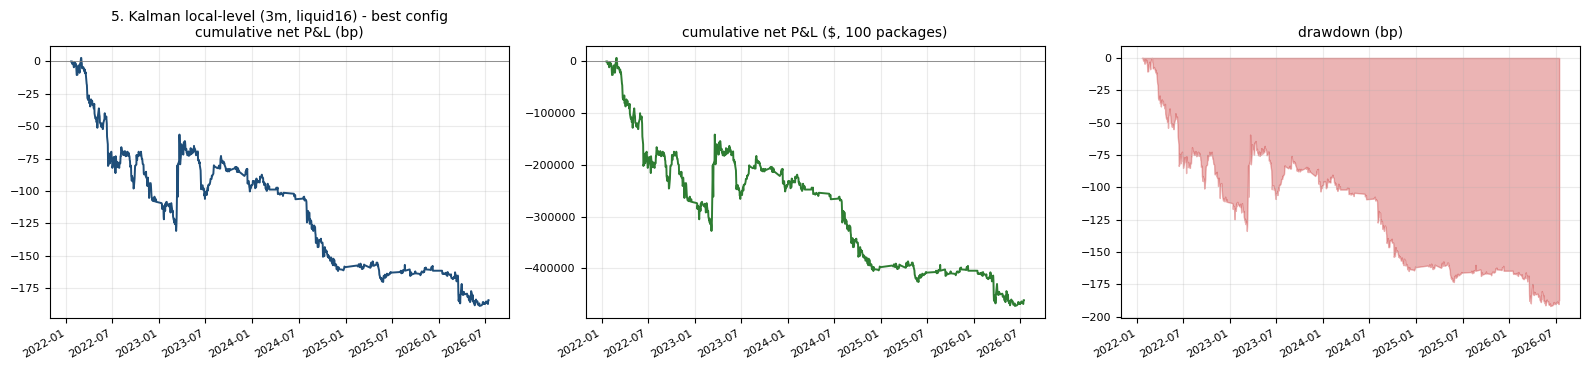


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
H22-M22-U22   -1  2022-01-18 2022-01-19 2022-02-03    11  3.158      7.00       9.00     -2.00      1.5   -3.50  -8750.0 mean_reversion
M22-U22-Z22   -1  2022-01-26 2022-01-27 2022-02-08     8  3.351      6.50       6.00      0.50      1.5   -1.00  -2500.0 mean_reversion
U22-Z22-H23   -1  2022-01-31 2022-02-01 2022-03-02    20  3.188      2.00       4.50     -2.50      1.5   -4.00 -10000.0       max_hold
H22-M22-U22   -1  2022-02-04 2022-02-07 2022-02-25    13  4.482     14.00      11.25      2.75      1.5    1.25   3125.0 mean_reversion
M22-U22-Z22   -1  2022-02-10 2022-02-11 2022-02-28    10  7.125     13.00       4.50      8.50      1.5    7.00  17500.0 mean_reversion
H22-M22-U22    1  2022-03-01 2022-03-02 2022-03-04     2 -4.387     18.25      15.75     -2.50      1.5   -4.00 -10000.0 mean_reversion
U23-Z23-H24   -1  202

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       171    11.000     0.439      -1.079       -184.50  -1.051
half       162    11.160     0.389      -1.213       -196.50  -1.094
band       162    11.160     0.389      -1.213       -196.50  -1.094
  t5       260     4.954     0.281      -1.307       -339.75  -2.271
 t10       193     9.731     0.332      -1.544       -298.00  -1.785
 t20       135    19.289     0.348      -0.981       -132.50  -0.510

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 171          72.0       0.421     0.655       180000.0
           0.5 171         -13.5      -0.079     0.614       -33750.0
           1.0 171         -99.0      -0.579     0.550      -247500.0
           1.5 171        -184.5      -1.079     0.439      -461250.0
           2.5 171        -355.5      -2.079     0.298      -888750.0
           4.0 171        -612.0      -3.57

5. Kalman local-level (3m, liquid16) - MEDIAN config (the anti-selection control)  |  momentum|z1.5|half|hold20|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades   385   skipped    4   hit 24%   avg -1.458bp   avg hold 13.0d
  total    -561.50bp   $   -1,403,750   gross +16.00bp
  daily-MTM Sharpe -2.08   maxDD -587.00bp ($-1,467,500)   worst trade -26.00bp
  t(trade) -6.22   NW t(daily) -4.27   non-overlap SR -0.26   DSR p=0.000 over 128 trials

  LEAGUE ROW  5. Kalman local-level (3m, liquid16) / best-config: MARGINAL-maker-only  (taker -355.50bp, maker +72.00bp, DSR p=0.000)

  LEAGUE ROW  5. Kalman local-level (3m, liquid16) / median-config: MARGINAL-maker-only  (taker -946.50bp, maker +16.00bp, DSR p=0.000)


In [5]:
GRID = {"q": CONFIG["qs"], "entry_z": CONFIG["entry_zs"],
        "exit_style": CONFIG["exits"], "direction": CONFIG["directions"]}
PARAMS = ["q", "entry_z", "exit_style", "direction"]
out = run_family("5. Kalman local-level (3m, liquid16)", lab=lab,
                 signal_fn=lambda L, q: kalman_level_signal(L, q=q,
                                                            r=CONFIG["r_obs"]),
                 grid_spec=GRID, params=PARAMS, base=BASE, cls="kalman",
                 note="standardised one-step-ahead innovation")

## 4. Dynamic hedge ratios

The belly regressed on both wings with drifting coefficients. Two things to
read: where the coefficients actually sit relative to the butterfly's implied
`(0.5, 0.5)`, and whether the resulting residual is more tradeable than the
asserted fly.

In [6]:
hr_rows, hr_sig = [], {}
for key, g in st.groupby("key"):
    g = g.sort_values("as_of")
    if len(g) < 300:
        continue
    idx = pd.DatetimeIndex(g["as_of"])
    y = pd.Series(g["leg1_value"].to_numpy(float), index=idx)
    Xw = pd.DataFrame({"front": g["leg0_value"].to_numpy(float),
                       "back": g["leg2_value"].to_numpy(float)}, index=idx)
    kh = kalman_hedge_ratio(y, Xw, delta=1e-4, r=1e-3)
    hr_sig[key] = kh["z"]
    hr_rows.append({"key": key,
                    "beta_front_end": kh["beta_front"].iloc[-1],
                    "beta_back_end": kh["beta_back"].iloc[-1],
                    "beta_front_sd": kh["beta_front"].std(),
                    "beta_back_sd": kh["beta_back"].std(),
                    "resid_sd_bp": kh["resid"].std() * 100,
                    "resid_hl": half_life(kh["resid"] * 100)})
hr = pd.DataFrame(hr_rows)
print(hr.round(3).to_string(index=False))
print("\nthe butterfly asserts beta_front = beta_back = 0.5:")
print(hr[["beta_front_end", "beta_back_end", "beta_front_sd", "beta_back_sd",
          "resid_sd_bp", "resid_hl"]].describe().round(3).to_string())

        key  beta_front_end  beta_back_end  beta_front_sd  beta_back_sd  resid_sd_bp  resid_hl
H23-M23-U23           0.383          0.654          0.041         0.038        7.111       NaN
H24-M24-U24           0.431          0.604          0.015         0.029        6.401     0.106
H25-M25-U25           0.442          0.592          0.025         0.032        5.575     0.133
H26-M26-U26           0.467          0.557          0.017         0.023       10.596     0.122
H27-M27-U27           0.494          0.523          0.008         0.009       14.165     0.105
H28-M28-U28           0.470          0.530          0.010         0.012       14.285     0.083
M23-U23-Z23           0.464          0.587          0.022         0.024        7.105       NaN
M24-U24-Z24           0.469          0.568          0.016         0.029        6.202     0.114
M25-U25-Z25           0.448          0.581          0.011         0.017        5.419     0.116
M26-U26-Z26           0.462          0.547        


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/48 configs


  48 configs | median +0.00bp | IQR [-2.75, +0.00] | 23% net-positive | best +15.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 delta  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
   0.0      3.0         z0      fade         1     1.000      15.000          15.0        37500.0   9.543        0.0
   0.0      2.0         z0      fade         1     1.000      14.500          14.5        36250.0   4.098       -3.0
   0.0      2.5         z0      fade         1     1.000      14.500          14.5        36250.0   4.098       -3.0
   0.0      3.0        t10      fade         1     1.000      11.500          11.5        28750.0   3.446      -10.5
   0.0      2.5         t5      fade         1     1.000      11.000          11.0        27500.0   3.444       -3.0
   0.0      1.5         z0      fade         3     0.667       3.667          11.0        27500.0   1.997      -14.0
   0.0      2.0         t

5b. Kalman dynamic hedge ratio (3m, liquid16) - best config  |  fade|z3.0|z0|hold20|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  belly on wings with drifting betas; fly still the traded package
  trades     1   skipped    0   hit 100%   avg +15.000bp   avg hold 4.0d
  total     +15.00bp   $      +37,500   gross +16.50bp
  daily-MTM Sharpe +9.54   maxDD +0.00bp ($+0)   worst trade +15.00bp
  t(trade) +nan   NW t(daily) +nan   non-overlap SR +nan   DSR p=nan over 48 trials


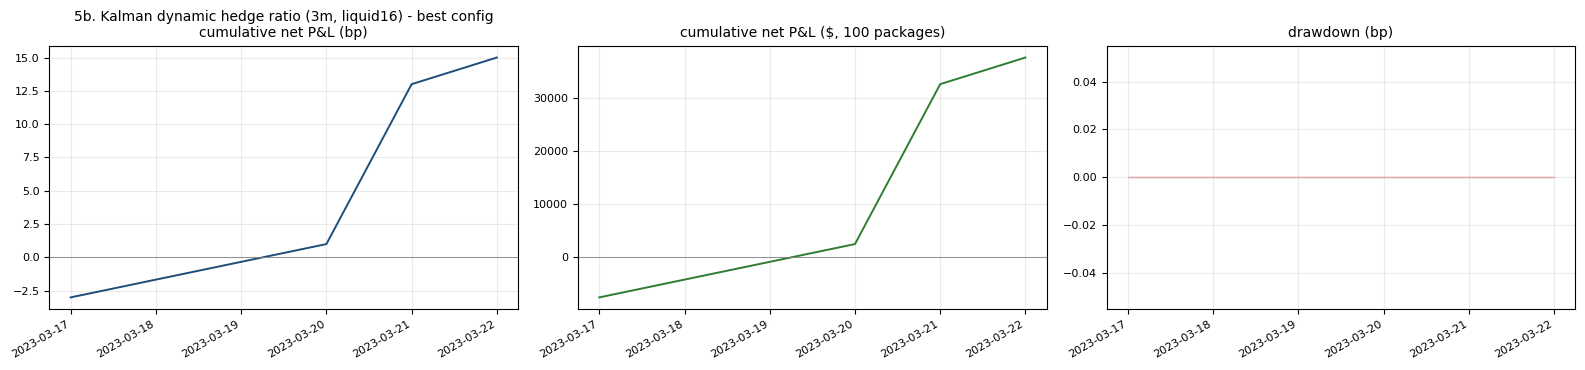


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
M23-U23-Z23    1  2023-03-15 2023-03-16 2023-03-22     4 -3.433     -10.5        6.0      16.5      1.5    15.0  37500.0 mean_reversion

  exit comparison:
exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0         1       4.0       1.0        15.0          15.0   9.543
half         1       3.0       1.0        11.5          11.5   9.013
band         1       3.0       1.0        11.5          11.5   9.013
  t5         1       5.0       1.0         7.0           7.0   2.748
 t10         1      10.0       1.0        11.5          11.5   3.446
 t20         1      20.0       1.0        15.0          15.0   2.777

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0  1          16.5        16.5       1.0        41250.0
      


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5         1            16.5          15.0        15.0       1.0   9.543        0.0       4.0          False             False
         belly       1            0.5         1            11.0          10.5        10.5       1.0   1.256      -11.0       4.0          False             False
belly_vs_front       2            1.0         1             6.0           5.0         5.0       1.0   3.201       -5.0       4.0          False             False
 belly_vs_back       2            1.0         1            10.5           9.5         9.5       1.0  11.510        0.0       4.0          False              True
  -> fly beats every linear shadow on net bp


5b. Kalman dynamic hedge ratio (3m, liquid16) - MEDIAN config (the anti-selection control)  |  fade|z1.5|z0|hold20|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  no trades

  LEAGUE ROW  5b. Kalman dynamic hedge ratio (3m, liquid16) / best-config: DEAD (too few trades)  (taker +14.00bp, maker +16.50bp, DSR p=nan)

  LEAGUE ROW  5b. Kalman dynamic hedge ratio (3m, liquid16) / median-config: DEAD (too few trades)  (taker +0.00bp, maker +0.00bp, DSR p=nan)


In [7]:
def hedge_sig(L, delta):
    out = {}
    for key, g in st.groupby("key"):
        g = g.sort_values("as_of")
        if len(g) < 200:
            continue
        idx = pd.DatetimeIndex(g["as_of"])
        y = pd.Series(g["leg1_value"].to_numpy(float), index=idx)
        Xw = pd.DataFrame({"front": g["leg0_value"].to_numpy(float),
                           "back": g["leg2_value"].to_numpy(float)}, index=idx)
        out[key] = kalman_hedge_ratio(y, Xw, delta=delta, r=1e-3)["z"]
    return pd.DataFrame(out).reindex(index=L.index, columns=L.columns)


out_hr = run_family(
    "5b. Kalman dynamic hedge ratio (3m, liquid16)", lab=lab, signal_fn=hedge_sig,
    grid_spec={"delta": CONFIG["deltas"], "entry_z": CONFIG["entry_zs"],
               "exit_style": ("z0", "t5", "t10"),
               "direction": CONFIG["directions"]},
    params=["delta", "entry_z", "exit_style", "direction"],
    base=BASE, cls="kalman",
    note="belly on wings with drifting betas; fly still the traded package")

## 5. Per-slot and long window

In [8]:
per = per_slot_table(out["result"], lab)
if not per.empty:
    print(per.round(3).to_string(index=False))

 slot           cm  n   hit  avg_net_bp  total_net_bp  total_gross_bp  avg_hold  total_net_usd
  2.0       SFR123 56 0.446      -1.625         -91.0            -7.0     9.464      -227500.0
  3.0       SFR234 37 0.432      -0.730         -27.0            28.5    12.081       -67500.0
  4.0       SFR345 27 0.481      -1.296         -35.0             5.5    12.148       -87500.0
  5.0       SFR456 21 0.381      -1.048         -22.0             9.5    12.190       -55000.0
  6.0       SFR567 14 0.357      -0.464          -6.5            14.5     9.643       -16250.0
  7.0       SFR678  5 0.400      -0.800          -4.0             3.5    14.600       -10000.0
  8.0       SFR789  4 0.500      -1.875          -7.5            -1.5    11.250       -18750.0
  9.0   SFR-8-9-10  4 0.250       1.250           5.0            11.0    10.250        12500.0
 10.0  SFR-9-10-11  2 1.000       1.000           2.0             5.0     9.000         5000.0
 11.0 SFR-10-11-12  1 1.000       1.500           


### GRID  (42 keys, 1907 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/128 configs


  50/128 configs


  75/128 configs


  100/128 configs


  125/128 configs


  128 configs | median -581.25bp | IQR [-758.00, -432.88] | 0% net-positive | best -208.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
    q  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
0.010      3.0         z0      fade       178     0.416      -1.171       -208.50      -521250.0  -1.091    -214.25
0.010      3.0       half      fade       169     0.361      -1.331       -225.00      -562500.0  -1.177    -227.50
0.010      3.0       half  momentum       169     0.254      -1.669       -282.00      -705000.0  -1.491    -284.00
0.001      3.0         z0      fade       226     0.376      -1.262       -285.25      -713125.0  -0.975    -285.75
0.010      3.0        t10  momentum       203     0.261      -1.419       -288.00      -720000.0  -1.601    -288.75
0.001      3.0       half      fade       223     0.350      -1.327       -296.00      -740000.0  -1.123    -298.75
0.010      2.5        t10

5c. Kalman local-level (3m, front8, 2019+) - best config  |  fade|z3.0|z0|hold20|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  long history
  trades   178   skipped    2   hit 42%   avg -1.171bp   avg hold 11.1d
  total    -208.50bp   $     -521,250   gross +58.50bp
  daily-MTM Sharpe -1.09   maxDD -214.25bp ($-535,625)   worst trade -24.50bp
  t(trade) -2.91   NW t(daily) -2.55   non-overlap SR -0.31   DSR p=0.000 over 128 trials


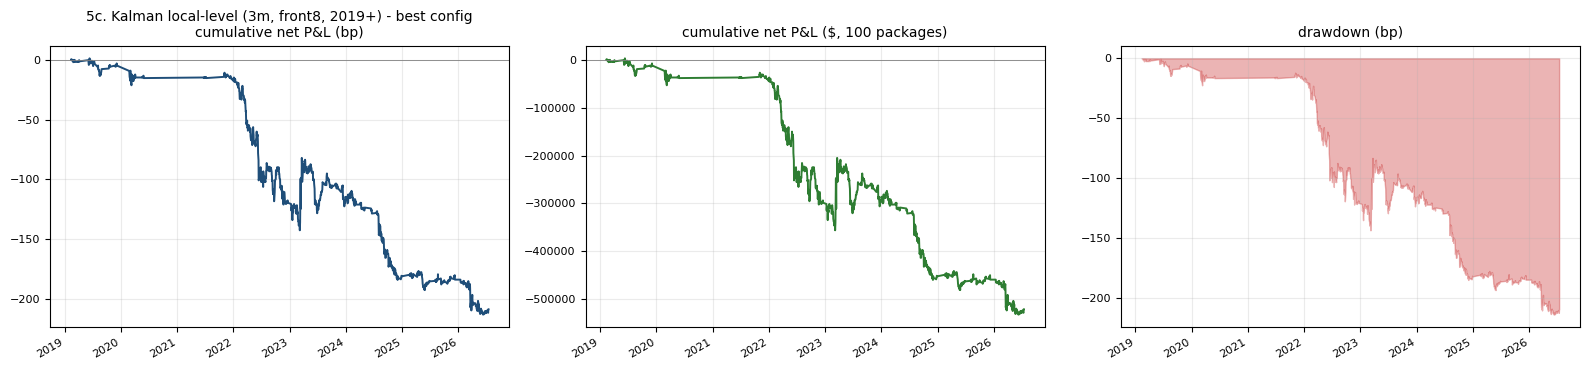


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
H19-M19-U19    1  2019-02-08 2019-02-11 2019-03-08    18 -3.044       0.0      -0.25     -0.25      1.5   -1.75  -4375.0 mean_reversion
M19-U19-Z19    1  2019-03-25 2019-03-26 2019-04-08     9 -3.534       0.5       2.50      2.00      1.5    0.50   1250.0 mean_reversion
U19-Z19-H20    1  2019-05-31 2019-06-03 2019-06-18    11 -3.678      -8.0      -3.00      5.00      1.5    3.50   8750.0 mean_reversion
Z19-H20-M20    1  2019-05-31 2019-06-03 2019-07-01    20 -3.452      -7.0      -7.50     -0.50      1.5   -2.00  -5000.0       max_hold
M19-U19-Z19    1  2019-06-03 2019-06-04 2019-06-18    10 -7.265      -8.0     -10.00     -2.00      1.5   -3.50  -8750.0       max_hold
U19-Z19-H20   -1  2019-07-01 2019-07-02 2019-07-15     8  4.002      -1.5      -3.00      1.50      1.5   -0.00     -0.0 mean_reversion
U19-Z19-H20    1  201

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       178    11.146     0.416      -1.171       -208.50  -1.091
half       169    11.237     0.361      -1.331       -225.00  -1.177
band       169    11.237     0.361      -1.331       -225.00  -1.177
  t5       273     4.952     0.271      -1.418       -387.25  -2.371
 t10       203     9.709     0.340      -1.581       -321.00  -1.778
 t20       143    19.126     0.315      -1.168       -167.00  -0.611

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 178          58.5       0.329     0.635       146250.0
           0.5 178         -30.5      -0.171     0.601       -76250.0
           1.0 178        -119.5      -0.671     0.534      -298750.0
           1.5 178        -208.5      -1.171     0.416      -521250.0
           2.5 178        -386.5      -2.171     0.287      -966250.0
           4.0 178        -653.5      -3.67

5c. Kalman local-level (3m, front8, 2019+) - MEDIAN config (the anti-selection control)  |  fade|z2.5|half|hold20|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades   302   skipped    1   hit 30%   avg -1.920bp   avg hold 16.2d
  total    -579.75bp   $   -1,449,375   gross -126.75bp
  daily-MTM Sharpe -1.85   maxDD -579.75bp ($-1,449,375)   worst trade -29.50bp
  t(trade) -6.52   NW t(daily) -5.13   non-overlap SR -0.26   DSR p=0.000 over 128 trials

  LEAGUE ROW  5c. Kalman local-level (3m, front8, 2019+) / best-config: MARGINAL-maker-only  (taker -386.50bp, maker +58.50bp, DSR p=0.000)

  LEAGUE ROW  5c. Kalman local-level (3m, front8, 2019+) / median-config: DEAD  (taker -881.75bp, maker -126.75bp, DSR p=0.000)


In [9]:
lab8 = load_lab(CONFIG["primary_structure"], CONFIG["long_window"])
out8 = run_family("5c. Kalman local-level (3m, front8, 2019+)", lab=lab8,
                  signal_fn=lambda L, q: kalman_level_signal(L, q=q,
                                                             r=CONFIG["r_obs"]),
                  grid_spec=GRID, params=PARAMS, base=BASE, cls="kalman",
                  note="long history")